Here, we compare Logistic Regression, XGBoost, SVC, and RandomForest's performance via nestedCV.

# Imports

In [36]:
import pandas as pd
import numpy as np

# Get and Format Data

In [37]:
def prepare_data(data, year):
    data = data.rename(columns=lambda x: x[2:] if x[1]=='_' else x)
    data['year'] = year
    data = data.sample(frac=1)
    return data

In [38]:
amazon_train_sets = [prepare_data(pd.read_csv(f"datasets/fixed/amazon_train_{year}_fixed.csv"), year) for year in range(2021, 2024)]
amazon_train = pd.concat(amazon_train_sets, axis=0)

taiga_train_sets = [prepare_data(pd.read_csv(f"datasets/fixed/taiga_train_{year}_fixed.csv"), year) for year in range(2021, 2024)]
taiga_train = pd.concat(taiga_train_sets, axis=0)

borneo_train_sets = [prepare_data(pd.read_csv(f"datasets/fixed/borneo_train_{year}_fixed.csv"), year) for year in range(2021, 2024)]
borneo_train = pd.concat(borneo_train_sets, axis=0)

train_set = pd.concat([amazon_train, taiga_train, borneo_train], axis=0)
train_set = train_set.sample(frac=1)
train_set = train_set.sort_values(by='year').reset_index()
print(train_set.head())
print(train_set.groupby('year')['class'].count())

   index system:index  NBR_delta_lag4  NBR_lag4  NDMI_delta_lag4  NDMI_lag4  \
0    800     1_1812_0       -0.000947  0.362268         0.008083   0.244166   
1    151     1_1151_0       -0.027937  0.323748        -0.019700   0.185530   
2    701     1_1701_0        0.026159  0.340955         0.024905   0.202075   
3    894     1_1894_0        0.060520  0.244322         0.070222   0.121172   
4    939     1_1939_0        0.059964  0.197749         0.062111   0.104188   

   NDVI_delta_lag4  NDVI_lag4  SR_B4_delta_lag4  SR_B4_lag4  ...  SR_B5_lag1  \
0        -0.003611   0.406069             158.0      8220.0  ...     19252.0   
1        -0.026952   0.383625             -35.0      8285.0  ...     19911.0   
2         0.028152   0.396273            -134.5      8115.0  ...     17861.5   
3         0.064814   0.312921           -1282.0      8774.0  ...     16692.5   
4         0.069238   0.284508            -493.5      8238.0  ...     13522.0   

   SR_B6_delta_lag1  SR_B6_lag1  SR_B7_delta

In [39]:
print(amazon_train.columns)

Index(['system:index', 'NBR_delta_lag4', 'NBR_lag4', 'NDMI_delta_lag4',
       'NDMI_lag4', 'NDVI_delta_lag4', 'NDVI_lag4', 'SR_B4_delta_lag4',
       'SR_B4_lag4', 'SR_B5_delta_lag4', 'SR_B5_lag4', 'SR_B6_delta_lag4',
       'SR_B6_lag4', 'SR_B7_delta_lag4', 'SR_B7_lag4', 'NBR_delta_lag3',
       'NBR_lag3', 'NDMI_delta_lag3', 'NDMI_lag3', 'NDVI_delta_lag3',
       'NDVI_lag3', 'SR_B4_delta_lag3', 'SR_B4_lag3', 'SR_B5_delta_lag3',
       'SR_B5_lag3', 'SR_B6_delta_lag3', 'SR_B6_lag3', 'SR_B7_delta_lag3',
       'SR_B7_lag3', 'NBR_delta_lag2', 'NBR_lag2', 'NDMI_delta_lag2',
       'NDMI_lag2', 'NDVI_delta_lag2', 'NDVI_lag2', 'SR_B4_delta_lag2',
       'SR_B4_lag2', 'SR_B5_delta_lag2', 'SR_B5_lag2', 'SR_B6_delta_lag2',
       'SR_B6_lag2', 'SR_B7_delta_lag2', 'SR_B7_lag2', 'NBR_delta_lag1',
       'NBR_lag1', 'NDMI_delta_lag1', 'NDMI_lag1', 'NDVI_delta_lag1',
       'NDVI_lag1', 'SR_B4_delta_lag1', 'SR_B4_lag1', 'SR_B5_delta_lag1',
       'SR_B5_lag1', 'SR_B6_delta_lag1', 'SR_B6_lag1', 

# Feature Selection

In [40]:
# select all feature columns except metadata/target columns
exclude_cols = {'index', 'system:index', 'class', 'latitude', 'longitude', '.geo', 'year'}
all_features = [c for c in train_set.columns if c not in exclude_cols]
# drop columns ending with "delta_lag1"
drop_cols = [c for c in train_set.columns if c.endswith('delta_lag1')]
train_set = train_set.drop(columns=drop_cols)
all_features = [c for c in all_features if c not in drop_cols]
print(f"Dropped {len(drop_cols)} columns: {drop_cols}")

Dropped 7 columns: ['NBR_delta_lag1', 'NDMI_delta_lag1', 'NDVI_delta_lag1', 'SR_B4_delta_lag1', 'SR_B5_delta_lag1', 'SR_B6_delta_lag1', 'SR_B7_delta_lag1']


In [41]:
X_train = train_set[all_features]
y_train = train_set['class']
print(X_train.columns)

Index(['NBR_delta_lag4', 'NBR_lag4', 'NDMI_delta_lag4', 'NDMI_lag4',
       'NDVI_delta_lag4', 'NDVI_lag4', 'SR_B4_delta_lag4', 'SR_B4_lag4',
       'SR_B5_delta_lag4', 'SR_B5_lag4', 'SR_B6_delta_lag4', 'SR_B6_lag4',
       'SR_B7_delta_lag4', 'SR_B7_lag4', 'NBR_delta_lag3', 'NBR_lag3',
       'NDMI_delta_lag3', 'NDMI_lag3', 'NDVI_delta_lag3', 'NDVI_lag3',
       'SR_B4_delta_lag3', 'SR_B4_lag3', 'SR_B5_delta_lag3', 'SR_B5_lag3',
       'SR_B6_delta_lag3', 'SR_B6_lag3', 'SR_B7_delta_lag3', 'SR_B7_lag3',
       'NBR_delta_lag2', 'NBR_lag2', 'NDMI_delta_lag2', 'NDMI_lag2',
       'NDVI_delta_lag2', 'NDVI_lag2', 'SR_B4_delta_lag2', 'SR_B4_lag2',
       'SR_B5_delta_lag2', 'SR_B5_lag2', 'SR_B6_delta_lag2', 'SR_B6_lag2',
       'SR_B7_delta_lag2', 'SR_B7_lag2', 'NBR_lag1', 'NDMI_lag1', 'NDVI_lag1',
       'SR_B4_lag1', 'SR_B5_lag1', 'SR_B6_lag1', 'SR_B7_lag1'],
      dtype='object')


class               1.000000
SR_B7_lag1          0.256608
SR_B7_lag2          0.211558
SR_B6_lag1          0.211110
SR_B4_lag1          0.205267
SR_B7_lag3          0.194705
SR_B7_lag4          0.188136
SR_B6_lag2          0.174015
SR_B6_lag3          0.170756
SR_B6_lag4          0.160044
SR_B4_lag2          0.147745
SR_B5_lag3          0.124718
SR_B4_delta_lag4    0.120949
NDMI_delta_lag3     0.118556
SR_B4_delta_lag3    0.114682
NBR_delta_lag3      0.113435
NDVI_delta_lag3     0.113318
SR_B5_lag4          0.105433
SR_B4_lag3          0.104020
NDMI_delta_lag4     0.102236
NDVI_lag3           0.100666
SR_B7_delta_lag4    0.099147
NDMI_lag1           0.096929
SR_B7_delta_lag3    0.093743
NBR_delta_lag4      0.092605
SR_B4_lag4          0.090640
SR_B5_lag2          0.089939
NDVI_delta_lag4     0.084598
NDVI_lag4           0.083079
NDMI_delta_lag2     0.081137
NBR_delta_lag2      0.074497
SR_B4_delta_lag2    0.073035
SR_B5_lag1          0.069977
SR_B6_delta_lag4    0.068787
SR_B7_delta_la

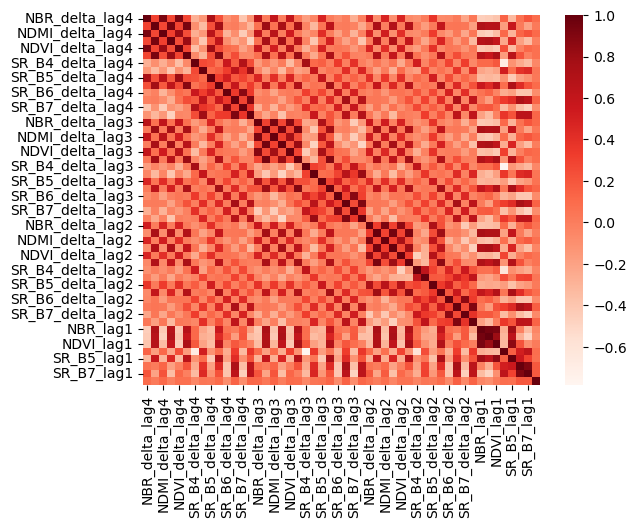

In [65]:
import seaborn as sns
sns.heatmap(pd.concat([amazon_train[all_features], amazon_train['class']], axis=1).corr(), cmap='Reds')
print(abs(pd.concat([amazon_train[all_features], amazon_train['class']], axis=1).corr(method='spearman')['class']).sort_values(ascending=False))

Features not well correlated...

# Compare Models

In [43]:
def custom_year_ts_split(df, year_col):
    """Custom CV splitter for our yearly data."""
    # Get unique years and sort them
    years = sorted(df[year_col].unique())
    
    # We need at least 2 years to do one split (Train Y1 -> Val Y2)
    for i in range(1, len(years)):
        # Training set: All years up to the current split
        train_indices = df[df[year_col].isin(years[:i])].index.values
        
        # Validation set: The very next year
        val_indices = df[df[year_col] == years[i]].index.values
        yield train_indices, val_indices

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_validate


## Logistic Regression

In [45]:

cv_iterator = custom_year_ts_split(train_set, 'year')
logistic_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', LogisticRegressionCV(
        cv=5, 
        l1_ratios=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], 
        max_iter=5000,
        solver='saga',
        random_state=1,
        use_legacy_attributes=False))])
logistic_results = cross_validate(
    logistic_pipe, 
    X_train, 
    y_train, 
    cv=cv_iterator, 
    return_estimator=True,
    scoring=['f1', 'precision', 'recall'], 
    return_train_score=True  # Crucial for detecting overfitting
)

In [46]:
print(f"Mean Test f1: {logistic_results['test_f1'].mean():.4f}")
print(f"Mean Test Precision: {logistic_results['test_precision'].mean():.4f}")
print(f"Mean Test Recall: {logistic_results['test_recall'].mean():.4f}")

print(f"Mean Train f1: {logistic_results['train_f1'].mean():.4f}")
print(f"Mean Train Precision: {logistic_results['train_precision'].mean():.4f}")
print(f"Mean Train Recall: {logistic_results['train_recall'].mean():.4f}")

print(f"Overfitting Ratio: {1-logistic_results['test_f1'].mean()/logistic_results['train_f1'].mean()}")

Mean Test f1: 0.5798
Mean Test Precision: 0.6111
Mean Test Recall: 0.5520
Mean Train f1: 0.6529
Mean Train Precision: 0.6421
Mean Train Recall: 0.6640
Overfitting Ratio: 0.11185901085749628


Logistic Regression exhibits bad f1 scores with high overfitting.

## XGBoost

In [47]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier

In [48]:
xgboost_param_grid = {
    'model__max_depth': Integer(3, 5),
    'model__min_child_weight': Integer(1, 200),
    'model__subsample': Real(0.7, 1),
    'model__colsample_bylevel': Real(0.5, 1),
    'model__colsample_bynode': Real(0.5, 1),
    'model__reg_lambda': Real(0, 10),
    'model__reg_alpha': Real(0, 10)
}

In [49]:
xgb_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))
])

tuner = BayesSearchCV(
    estimator=xgb_pipe,
    cv=5,
    n_iter=32,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1',
)

cv_iterator = custom_year_ts_split(train_set, 'year')

xgb_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [50]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(xgb_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_

    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {xgb_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {xgb_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {xgb_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {xgb_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {xgb_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {xgb_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-xgb_results['test_f1'].mean()/xgb_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__colsample_bylevel': 0.5076300926681656, 'model__colsample_bynode': 0.7080629624667893, 'model__max_depth': 3, 'model__min_child_weight': 5, 'model__reg_alpha': 7.641887213149321, 'model__reg_lambda': 1.7317139110453152, 'model__subsample': 0.9965052657687086})
Outer Fold 1 - Inner Mean Test Score:  0.674411
Outer Fold 1 - Inner Test Score STD:  0.015934
Outer Fold 1 - Inner Mean Train Score: 0.783594
Outer Fold 1 - Inner Train Score STD:  0.015934
Outer Fold 2 Parameters - OrderedDict({'model__colsample_bylevel': 0.5042633336172881, 'model__colsample_bynode': 0.6425409299266259, 'model__max_depth': 5, 'model__min_child_weight': 184, 'model__reg_alpha': 1.2703365806966163, 'model__reg_lambda': 5.171034253552897, 'model__subsample': 0.998340825794609})
Outer Fold 2 - Inner Mean Test Score:  0.663323
Outer Fold 2 - Inner Test Score STD:  0.018511
Outer Fold 2 - Inner Mean Train Score: 0.732022
Outer Fold 2 - Inner Train Score STD:  0.018511



XGBoost outperforms Logistic Regression and SVC, but has more risk of overfitting, and f1 scores remain objectively low.

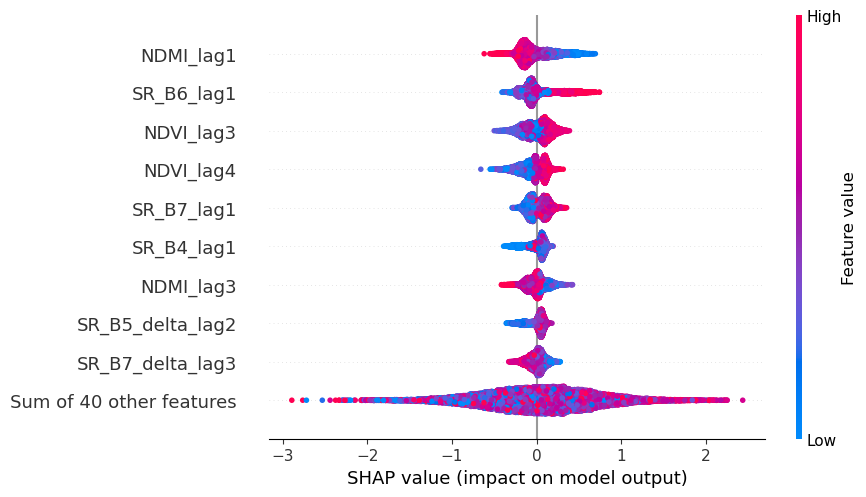

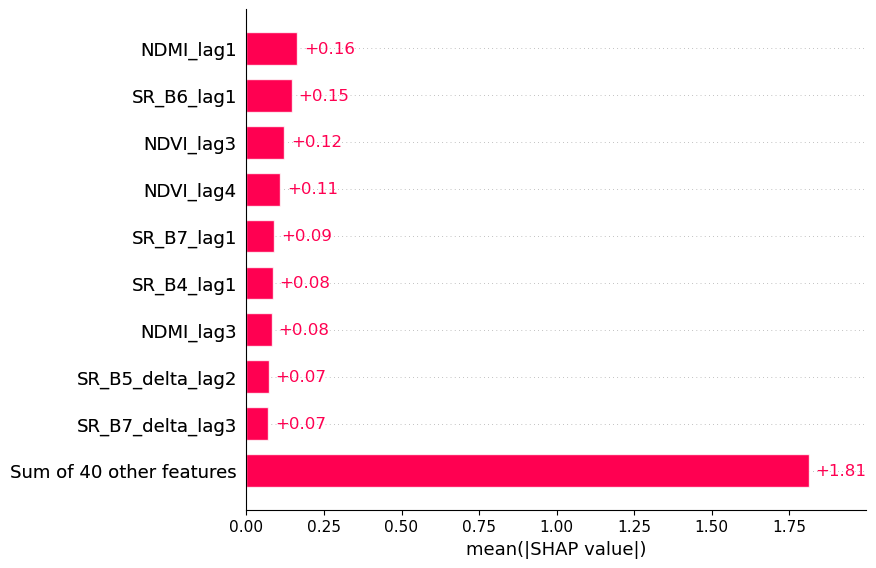

In [51]:
import shap
# Re-fit the tuner on full training data to get a final best estimator for interpretation
tuner.fit(X_train, y_train)
best_pipe = tuner.best_estimator_
model = best_pipe.named_steps['model']
explainer = shap.Explainer(model)
# Transform training data for the model component
X_trans = pd.DataFrame(
    best_pipe.named_steps['transformer'].transform(X_train),
    columns=all_features,
    index=X_train.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


## SVC

In [52]:
from sklearn.svm import SVC

In [53]:
svc_param_grid = {
    'model__C': Real(0.1, 10),
    'model__kernel': Categorical(['linear', 'poly', 'rbf'])
}

In [54]:
svc_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', SVC(random_state=1))])

tuner = BayesSearchCV(
    estimator=svc_pipe,
    cv=5,
    n_iter=32,
    search_spaces=svc_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1'
)

cv_iterator = custom_year_ts_split(train_set, 'year')

svc_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [55]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(svc_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_
    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {svc_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {svc_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {svc_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {svc_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {svc_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {svc_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-svc_results['test_f1'].mean()/svc_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__C': 5.695599205116403, 'model__kernel': 'rbf'})
Outer Fold 1 - Inner Mean Test Score:  0.666508
Outer Fold 1 - Inner Test Score STD:  0.015736
Outer Fold 1 - Inner Mean Train Score: 0.738924
Outer Fold 1 - Inner Train Score STD:  0.015736
Outer Fold 2 Parameters - OrderedDict({'model__C': 1.4452220339627142, 'model__kernel': 'rbf'})
Outer Fold 2 - Inner Mean Test Score:  0.651471
Outer Fold 2 - Inner Test Score STD:  0.011005
Outer Fold 2 - Inner Mean Train Score: 0.689032
Outer Fold 2 - Inner Train Score STD:  0.011005

Overall Metrics
Mean Test f1: 0.57646285
Mean Test Precision: 0.63354536
Mean Test Recall: 0.52883410
Mean Train f1: 0.71118987
Mean Train Precision: 0.71976325
Mean Train Recall: 0.70282063
Overfitting Ratio: 0.18943889339765096


SVC beats Logistic Regression, but loses to XGBoost, with strong overfitting.

## Random Forest

In [56]:
from sklearn.ensemble import RandomForestClassifier

In [59]:
rf_param_grid = {
    'model__max_depth': Integer(2, 12),
    'model__min_samples_split': Integer(2, 40),
    'model__min_samples_leaf': Integer(2, 40),
    'model__max_features': Real(0.1, 1),
}

In [62]:
rf_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', RandomForestClassifier(random_state=1))])

tuner=BayesSearchCV(estimator=rf_pipe, cv=5, refit='f1', search_spaces=rf_param_grid,
        return_train_score=True,
        random_state=1,
        scoring='f1')

cv_iterator = custom_year_ts_split(train_set, 'year')

rf_results = cross_validate(
    tuner,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [63]:
# # Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
# for outer_fold, outer_estimator in enumerate(rf_results['estimator'], start=1):
#     search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
#     inner_results = pd.DataFrame(search.cv_results_)
#     best_idx = search.best_index_
#     print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
#     mean_test = inner_results.loc[best_idx, "mean_test_score"]
#     std_test = inner_results.loc[best_idx, "std_test_score"]
#     print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
#     print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

#     if "mean_train_score" in inner_results.columns:
#         mean_train = inner_results.loc[best_idx, "mean_train_score"]
#         std_train = inner_results.loc[best_idx, "std_train_score"]
#         print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
#         print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_train:.6f}")
#     else:
#         print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {rf_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {rf_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {rf_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {rf_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {rf_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {rf_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-rf_results['test_f1'].mean()/rf_results['train_f1'].mean()}")


Overall Metrics
Mean Test f1: 0.59720747
Mean Test Precision: 0.63672837
Mean Test Recall: 0.56236145
Mean Train f1: 0.90438951
Mean Train Precision: 0.89596981
Mean Train Recall: 0.91297370
Overfitting Ratio: 0.33965679568531704


Random Forest wildly overfits.

# Observations
* All models do badly. Yay! 
    * The Landsat bands may not be useful in predicting deforestation--at least for a global model. 
* Precision > Recall.
* Best Model: XGBoost. But in general, classical ML seems to fail here.